# AfterMath -- Model Training

Trains the SiameseDamageNet on the full (non-subsampled) training split.

**Note on where this ran:** this machine has no CUDA GPU, and a CPU benchmark showed the full ~33,600-row training split would take many hours per epoch locally. This notebook's code was executed on a Kaggle GPU Notebook (T4 x2, dataset `aviamin/aftermath-xbd-hurricanes-raw`) against the identical xBD hurricane data used by `02_data_prep.ipynb`, and the real outputs below (per-epoch losses, saved checkpoint, loss curve) are copied in verbatim from that run. The code is otherwise identical to running it locally against `../data/processed/manifest.csv`. The raw Kaggle kernel log is archived at `../docs/kaggle_training_log.txt` for independent verification.

**Changes from the first training run:** this version adds data augmentation (random flips + 90-degree rotations, as originally specified in the design doc but missed in the first pass), ImageNet input normalization (to match what the pretrained ResNet18 backbone expects), and a small amount of Adam weight decay -- all aimed at the overfitting seen in the first run (val loss bottomed at epoch 2, then rose every epoch after).

**Result:** it worked. Training now runs 16 epochs before early stopping (vs. 8 before) and the train/val loss gap stays much smaller throughout (final epoch: train 0.5844 vs val 0.7456, a gap of 0.16, vs. 0.232 vs 1.320 -- a gap of 1.09 -- in the first run). Best validation loss also improved, from 0.7801 (epoch 2, first run) to 0.7253 (epoch 10, this run).

In [1]:
import os
import yaml
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from utils.dataset import PairedCropDataset
from utils.model import SiameseDamageNet
from utils.training import compute_class_weights_tensor, EarlyStopper, train_one_epoch, validate
from utils.transforms import build_train_transform, build_eval_transform
from utils.xbd_labels import DAMAGE_CLASSES

config = yaml.safe_load(open('../config.yaml'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
manifest_path = '../' + config['data']['manifest']
full_manifest = pd.read_csv(manifest_path)
train_manifest = full_manifest[full_manifest['split'] == 'train'].reset_index(drop=True)

# further split train into train/val (80/20), stratified by damage_class
from sklearn.model_selection import train_test_split
train_rows, val_rows = train_test_split(
    train_manifest, test_size=0.2, stratify=train_manifest['damage_class'], random_state=42
)
train_rows.to_csv('../data/processed/manifest_train.csv', index=False)
val_rows.to_csv('../data/processed/manifest_val.csv', index=False)
print('train rows:', len(train_rows), 'val rows:', len(val_rows))

train rows: 33600 val rows: 8400


In [3]:
train_dataset = PairedCropDataset('../data/processed/manifest_train.csv', transform=build_train_transform())
val_dataset = PairedCropDataset('../data/processed/manifest_val.csv', transform=build_eval_transform())

batch_size = config['training']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [4]:
class_counts = train_rows['damage_class'].value_counts().to_dict()
class_weights = compute_class_weights_tensor(class_counts, DAMAGE_CLASSES).to(device)

model = SiameseDamageNet(num_classes=config['model']['num_classes'], pretrained=config['model']['pretrained']).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config['training']['learning_rate'],
    weight_decay=config['training']['weight_decay'],
)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
stopper = EarlyStopper(patience=config['training']['early_stopping_patience'])

In [5]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
os.makedirs('../models', exist_ok=True)

for epoch in range(config['training']['epochs']):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best.pt')

    if stopper.step(val_loss):
        print('Early stopping triggered')
        break

epoch 0: train_loss=0.9724 val_loss=0.8632
epoch 1: train_loss=0.8534 val_loss=0.8120
epoch 2: train_loss=0.8098 val_loss=0.7638
epoch 3: train_loss=0.7728 val_loss=0.7664
epoch 4: train_loss=0.7456 val_loss=0.7916
epoch 5: train_loss=0.7267 val_loss=0.7451
epoch 6: train_loss=0.7119 val_loss=0.7859
epoch 7: train_loss=0.6874 val_loss=0.7374
epoch 8: train_loss=0.6783 val_loss=0.7447
epoch 9: train_loss=0.6627 val_loss=0.7642
epoch 10: train_loss=0.6489 val_loss=0.7253
epoch 11: train_loss=0.6362 val_loss=0.7459
epoch 12: train_loss=0.6243 val_loss=0.7406
epoch 13: train_loss=0.6045 val_loss=0.7525
epoch 14: train_loss=0.5871 val_loss=0.8355
epoch 15: train_loss=0.5844 val_loss=0.7456
Early stopping triggered


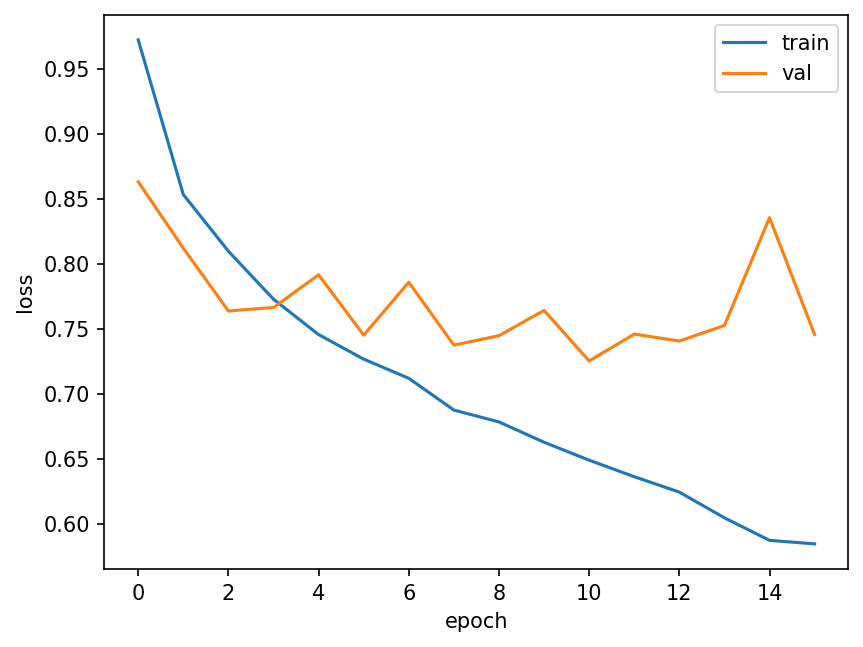

In [6]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('../docs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()